In [1]:
from pyspark.sql import SparkSession

spark = SparkSession.builder\
.master('local[*]')\
.getOrCreate()
sc = spark.sparkContext

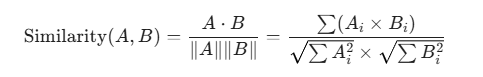

In [2]:
#데이터 준비: (영화id, 평점)
data_a = [(1,4), (2,5), (3,2)]
data_b = [(1,5), (2,4), (4,3)]

rdd_a = sc.parallelize(data_a)
rdd_b = sc.parallelize(data_b)

In [3]:
import numpy as np
#분모 계산
rdda1 = rdd_a.map(lambda x: x[1]**2).reduce(lambda a,b : a+b)
rdda2 = np.sqrt(rdda1)

rddb1 = rdd_b.map(lambda x: x[1]**2).reduce(lambda a,b : a+b)
rddb2 = np.sqrt(rddb1)

In [4]:
#분자 계산
#영화id를 기준으로 join하여 평점 곱해야함
joined_rdd = rdd_a.join(rdd_b)
dot_product = joined_rdd.map(lambda x: x[1][0]*x[1][1]).reduce(lambda a, b:a+b)

In [5]:
ans = dot_product / (rdda2 * rddb2)
print(f"Cosine Similarity: {ans}")

Cosine Similarity: 0.8432740427115677
